In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import gzip
import struct

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("PyTorch:", torch.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

PyTorch: 2.11.0+cpu
Dispositivo: cpu


In [3]:
carpeta_dataset = (
    '/content/drive/MyDrive/'
    'Colab Notebooks/'
    'Machine Learning Soto/'
    'Datasets/'
    'Lab05'
)

print(
    os.listdir(carpeta_dataset)
)

['emnist-letters-train-images-idx3-ubyte.gz', 'emnist-letters-train-labels-idx1-ubyte.gz', 'emnist-letters-test-images-idx3-ubyte.gz', 'emnist-letters-mapping.txt', 'emnist-letters-test-labels-idx1-ubyte.gz']


In [4]:
train_images_path = os.path.join(
    carpeta_dataset,
    'emnist-letters-train-images-idx3-ubyte.gz'
)

train_labels_path = os.path.join(
    carpeta_dataset,
    'emnist-letters-train-labels-idx1-ubyte.gz'
)

test_images_path = os.path.join(
    carpeta_dataset,
    'emnist-letters-test-images-idx3-ubyte.gz'
)

test_labels_path = os.path.join(
    carpeta_dataset,
    'emnist-letters-test-labels-idx1-ubyte.gz'
)

print(
    os.path.exists(train_images_path)
)

print(
    os.path.exists(train_labels_path)
)

print(
    os.path.exists(test_images_path)
)

print(
    os.path.exists(test_labels_path)
)

True
True
True
True


In [5]:
def cargar_imagenes(ruta):

    with gzip.open(
        ruta,
        'rb'
    ) as archivo:

        magic, cantidad, filas, columnas = struct.unpack(
            '>IIII',
            archivo.read(16)
        )

        datos = np.frombuffer(
            archivo.read(),
            dtype=np.uint8
        )

        datos = datos.reshape(
            cantidad,
            filas * columnas
        )

    return datos

In [6]:
def cargar_etiquetas(ruta):

    with gzip.open(
        ruta,
        'rb'
    ) as archivo:

        magic, cantidad = struct.unpack(
            '>II',
            archivo.read(8)
        )

        etiquetas = np.frombuffer(
            archivo.read(),
            dtype=np.uint8
        )

    return etiquetas

In [7]:
X_train = cargar_imagenes(
    train_images_path
)

y_train = cargar_etiquetas(
    train_labels_path
)

X_test = cargar_imagenes(
    test_images_path
)

y_test = cargar_etiquetas(
    test_labels_path
)

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (124800, 784)
y_train: (124800,)
X_test: (20800, 784)
y_test: (20800,)


In [8]:
y_train = (
    y_train.astype(np.int64)
    - 1
)

y_test = (
    y_test.astype(np.int64)
    - 1
)

print(
    "Etiqueta mínima:",
    y_train.min()
)

print(
    "Etiqueta máxima:",
    y_train.max()
)

print(
    "Cantidad clases:",
    len(np.unique(y_train))
)

Etiqueta mínima: 0
Etiqueta máxima: 25
Cantidad clases: 26


In [9]:
X_train = (
    X_train.astype(np.float32)
    / 255.0
)

X_test = (
    X_test.astype(np.float32)
    / 255.0
)

print(
    X_train.min(),
    X_train.max()
)

0.0 1.0


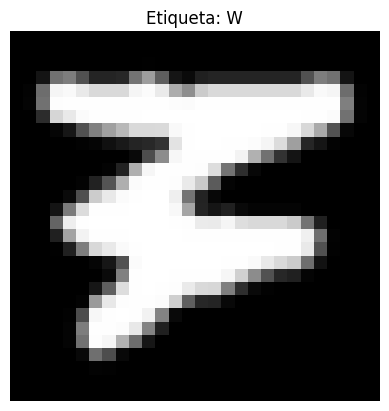

In [10]:
imagen = X_train[0].reshape(
    28,
    28
)

plt.imshow(
    imagen,
    cmap='gray'
)

plt.title(
    f"Etiqueta: {chr(y_train[0] + 65)}"
)

plt.axis('off')

plt.show()

In [11]:
class DatasetPersonalizado(
    torch.utils.data.Dataset
):

    def __init__(self, X, Y):

        self.X = torch.from_numpy(
            X
        ).float()

        self.Y = torch.from_numpy(
            Y
        ).long()


    def __len__(self):

        return len(self.X)


    def __getitem__(self, ix):

        return (
            self.X[ix],
            self.Y[ix]
        )

In [12]:
dataset = {

    'train': DatasetPersonalizado(
        X_train,
        y_train
    ),

    'test': DatasetPersonalizado(
        X_test,
        y_test
    )
}

print(
    "Train:",
    len(dataset['train'])
)

print(
    "Test:",
    len(dataset['test'])
)

Train: 124800
Test: 20800


In [13]:
dataloader = {

    'train': torch.utils.data.DataLoader(
        dataset['train'],
        batch_size=256,
        shuffle=True
    ),

    'test': torch.utils.data.DataLoader(
        dataset['test'],
        batch_size=256,
        shuffle=False
    )
}

In [14]:
x_b, y_b = next(
    iter(
        dataloader['train']
    )
)

print(
    "X:",
    x_b.shape
)

print(
    "y:",
    y_b.shape
)

X: torch.Size([256, 784])
y: torch.Size([256])


In [15]:
class ModeloOneVsAll(
    torch.nn.Module
):

    def __init__(self):

        super(
            ModeloOneVsAll,
            self
        ).__init__()

        self.linear = torch.nn.Linear(
            784,
            26
        )


    def forward(self, x):

        return self.linear(x)

In [16]:
model = ModeloOneVsAll().to(
    device
)

criterion = (
    torch.nn.BCEWithLogitsLoss()
)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

print(model)

ModeloOneVsAll(
  (linear): Linear(in_features=784, out_features=26, bias=True)
)


In [17]:
def fit(
    model,
    dataloader,
    optimizer,
    epochs=20
):

    criterion = (
        torch.nn.BCEWithLogitsLoss()
    )

    train_loss = []
    test_loss = []

    best_loss = float('inf')


    for e in range(
        1,
        epochs + 1
    ):

        model.train()

        _train_loss = []


        for x_b, y_b in dataloader['train']:

            x_b = x_b.to(device)

            y_b = y_b.to(device)


            y_onehot = torch.nn.functional.one_hot(
                y_b,
                num_classes=26
            ).float()


            logits = model(
                x_b
            )


            loss = criterion(
                logits,
                y_onehot
            )


            optimizer.zero_grad()

            loss.backward()

            optimizer.step()


            _train_loss.append(
                loss.item()
            )


        train_loss.append(
            np.mean(_train_loss)
        )


        model.eval()

        _test_loss = []


        with torch.no_grad():

            for x_b, y_b in dataloader['test']:

                x_b = x_b.to(device)

                y_b = y_b.to(device)


                y_onehot = torch.nn.functional.one_hot(
                    y_b,
                    num_classes=26
                ).float()


                logits = model(
                    x_b
                )


                loss = criterion(
                    logits,
                    y_onehot
                )


                _test_loss.append(
                    loss.item()
                )


        test_loss.append(
            np.mean(_test_loss)
        )


        if test_loss[-1] < best_loss:

            best_loss = test_loss[-1]

            torch.save(
                model.state_dict(),
                'mejor_modelo_lab05.pt'
            )


        print(
            f"Epoch {e}/{epochs} "
            f"loss {train_loss[-1]:.5f} "
            f"test_loss {test_loss[-1]:.5f}"
        )


    model.load_state_dict(
        torch.load(
            'mejor_modelo_lab05.pt',
            map_location=device
        )
    )


    return {

        'epoch':
            list(
                range(
                    1,
                    len(train_loss) + 1
                )
            ),

        'loss':
            train_loss,

        'test_loss':
            test_loss
    }

In [18]:
model = ModeloOneVsAll().to(
    device
)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1
)

hist = fit(
    model,
    dataloader,
    optimizer,
    epochs=20
)

Epoch 1/20 loss 0.19081 test_loss 0.15309
Epoch 2/20 loss 0.14429 test_loss 0.13650
Epoch 3/20 loss 0.13107 test_loss 0.12605
Epoch 4/20 loss 0.12246 test_loss 0.11898
Epoch 5/20 loss 0.11644 test_loss 0.11388
Epoch 6/20 loss 0.11200 test_loss 0.11006
Epoch 7/20 loss 0.10860 test_loss 0.10706
Epoch 8/20 loss 0.10588 test_loss 0.10464
Epoch 9/20 loss 0.10366 test_loss 0.10264
Epoch 10/20 loss 0.10181 test_loss 0.10095
Epoch 11/20 loss 0.10022 test_loss 0.09951
Epoch 12/20 loss 0.09887 test_loss 0.09825
Epoch 13/20 loss 0.09768 test_loss 0.09715
Epoch 14/20 loss 0.09661 test_loss 0.09616
Epoch 15/20 loss 0.09568 test_loss 0.09528
Epoch 16/20 loss 0.09482 test_loss 0.09448
Epoch 17/20 loss 0.09405 test_loss 0.09376
Epoch 18/20 loss 0.09334 test_loss 0.09309
Epoch 19/20 loss 0.09271 test_loss 0.09249
Epoch 20/20 loss 0.09209 test_loss 0.09192


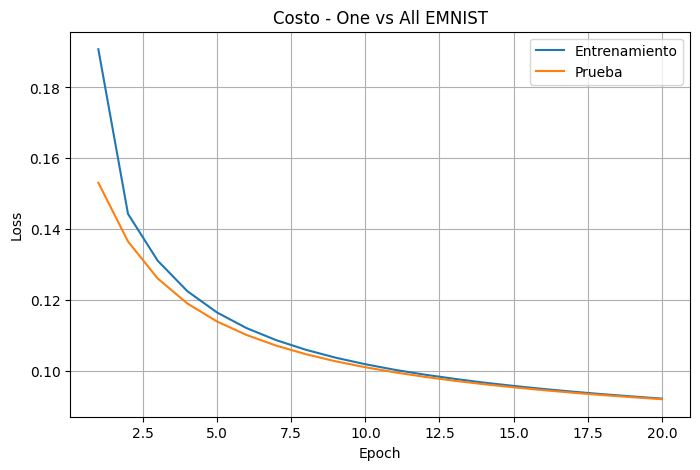

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist['epoch'],
    hist['loss'],
    label='Entrenamiento'
)

plt.plot(
    hist['epoch'],
    hist['test_loss'],
    label='Prueba'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Costo - One vs All EMNIST')

plt.legend()
plt.grid()
plt.show()

In [20]:
model.eval()

predicciones = []
valores_reales = []

with torch.no_grad():

    for x_b, y_b in dataloader['test']:

        x_b = x_b.to(device)

        logits = model(
            x_b
        )

        probabilidades = torch.sigmoid(
            logits
        )

        pred = torch.argmax(
            probabilidades,
            dim=1
        )

        predicciones.extend(
            pred.cpu().numpy()
        )

        valores_reales.extend(
            y_b.numpy()
        )

y_pred = np.array(
    predicciones
)

y_real = np.array(
    valores_reales
)

print(
    "Predicciones:",
    len(y_pred)
)

Predicciones: 20800


In [21]:
accuracy = accuracy_score(
    y_real,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

print(
    "Accuracy %:",
    accuracy * 100
)

Accuracy: 0.6303365384615385
Accuracy %: 63.03365384615385


In [22]:
matriz = confusion_matrix(
    y_real,
    y_pred
)

print(
    "Dimensión:",
    matriz.shape
)

print(matriz)

Dimensión: (26, 26)
[[440   5   5  33  15   8  23  25   1   1  16   0   9  54  29  10  31   2
    5   0  13   2  28  22   2  21]
 [  7 570   1  29  25   2  18  31  10   4   6  14   5   7  10  10   8   1
   11   2   5   0   1   6   0  17]
 [ 10   3 569   5  64   2  19   0   1   2  15   1   0   3  44  13   8  10
    2   3  13   1   3   0   0   9]
 [ 16  83   5 429   9   0   5  16   8  11  14  13   2   4  93   9  13   0
    5   0  13  16   7   0   0  29]
 [ 31  17  62   3 581  22   7   0   0   0  17   1   3   6   6   4   9  10
    6   2   2   0   2   2   0   7]
 [  8   1   3   1  19 528   2   2  13   5   2   5   2   2   0  86  31  34
    2  29   0   7   1   9   5   3]
 [ 43  34  20  11  16  20 314   4   2  39   2   2   2   4   8   9 163   3
   56  13   4   1   6   1  14   9]
 [ 32  19   3  27   7   3   0 462  28   0  46  12  18  72   1   3   0   2
    0   0  18  10  13  16   0   8]
 [  5   3   0   1   1   7   0   0 549  30   3  66   1   0   0   0   9   5
   13   8   4  14   0  47  10  24]

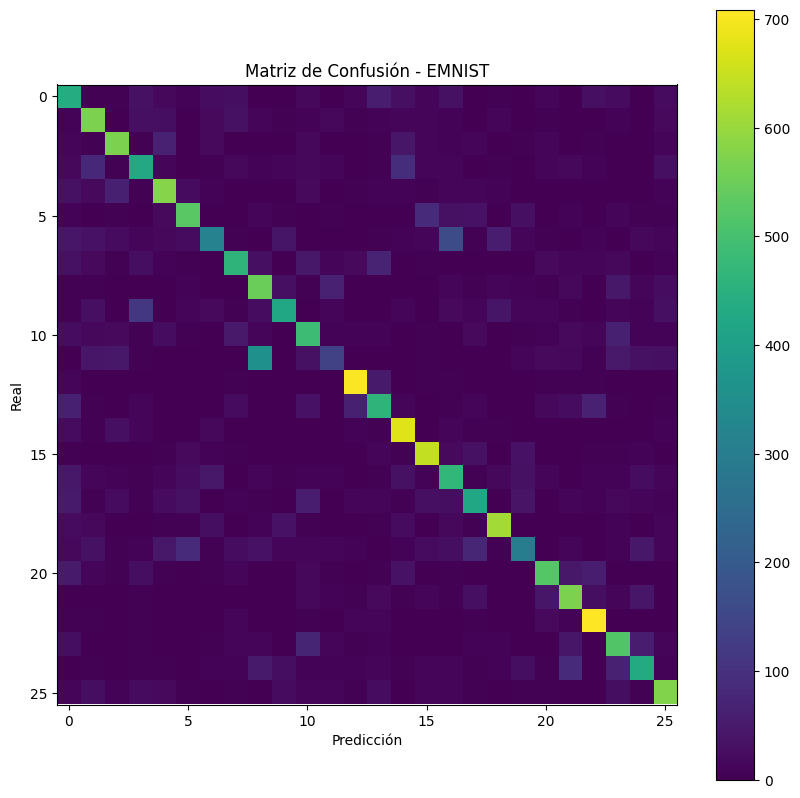

In [23]:
plt.figure(figsize=(10, 10))

plt.imshow(
    matriz
)

plt.title(
    'Matriz de Confusión - EMNIST'
)

plt.xlabel(
    'Predicción'
)

plt.ylabel(
    'Real'
)

plt.colorbar()

plt.show()

In [24]:
letras = [
    chr(i + 65)
    for i in range(26)
]

reporte = classification_report(
    y_real,
    y_pred,
    target_names=letras,
    digits=4
)

print(
    "REPORTE DE CLASIFICACIÓN"
)

print(reporte)

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           A     0.4651    0.5500    0.5040       800
           B     0.6083    0.7125    0.6563       800
           C     0.7060    0.7113    0.7086       800
           D     0.5630    0.5363    0.5493       800
           E     0.6558    0.7262    0.6892       800
           F     0.6761    0.6600    0.6679       800
           G     0.6027    0.3925    0.4754       800
           H     0.6619    0.5775    0.6168       800
           I     0.4867    0.6863    0.5695       800
           J     0.6801    0.5288    0.5949       800
           K     0.5566    0.6088    0.5815       800
           L     0.4299    0.1762    0.2500       800
           M     0.8055    0.8800    0.8411       800
           N     0.5908    0.5775    0.5841       800
           O     0.6723    0.8438    0.7483       800
           P     0.7159    0.8063    0.7584       800
           Q     0.5200    0.5863    0.5511       800
  

In [25]:
for i in range(20):

    real = chr(
        y_real[i] + 65
    )

    predicha = chr(
        y_pred[i] + 65
    )

    print(
        f"Real: {real} "
        f"→ Predicha: {predicha}"
    )

Real: A → Predicha: E
Real: A → Predicha: X
Real: A → Predicha: A
Real: A → Predicha: Q
Real: A → Predicha: A
Real: A → Predicha: A
Real: A → Predicha: A
Real: A → Predicha: A
Real: A → Predicha: X
Real: A → Predicha: A
Real: A → Predicha: N
Real: A → Predicha: A
Real: A → Predicha: S
Real: A → Predicha: A
Real: A → Predicha: N
Real: A → Predicha: A
Real: A → Predicha: E
Real: A → Predicha: A
Real: A → Predicha: Z
Real: A → Predicha: Q


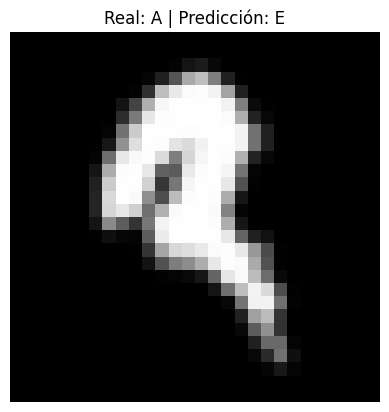

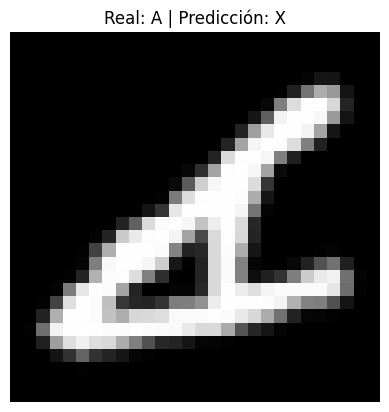

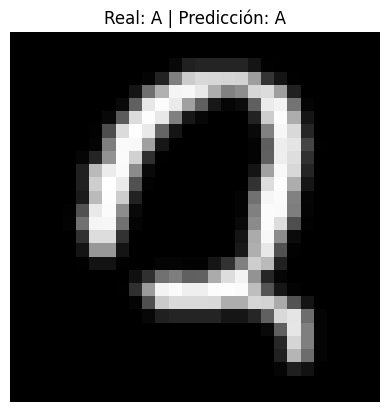

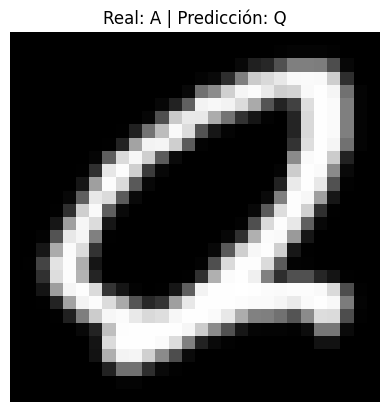

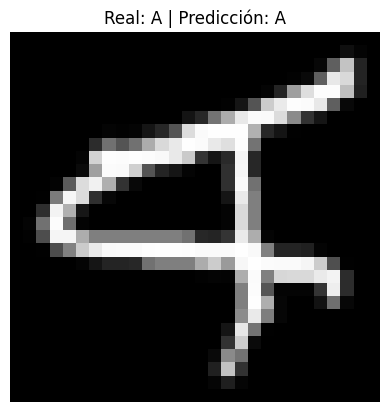

In [26]:
for i in range(5):

    plt.figure()

    plt.imshow(
        X_test[i].reshape(
            28,
            28
        ),
        cmap='gray'
    )

    real = chr(
        y_real[i] + 65
    )

    pred = chr(
        y_pred[i] + 65
    )

    plt.title(
        f"Real: {real} | Predicción: {pred}"
    )

    plt.axis('off')

    plt.show()

In [27]:
carpeta = (
    '/content/drive/MyDrive/'
    'Colab Notebooks/'
    'Machine Learning Soto/'
    'LabPyTorch/'
    'Lab05'
)

os.makedirs(
    carpeta,
    exist_ok=True
)

PATH = os.path.join(
    carpeta,
    'lab05_checkpoint.pt'
)

torch.save(
    {
        'model_state_dict':
            model.state_dict(),

        'optimizer_state_dict':
            optimizer.state_dict(),

        'accuracy':
            accuracy,

        'confusion_matrix':
            matriz,

        'clases':
            letras
    },

    PATH
)

print(
    "Modelo guardado en:"
)

print(PATH)

Modelo guardado en:
/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/LabPyTorch/Lab05/lab05_checkpoint.pt


In [28]:
print(
    "Existe:",
    os.path.exists(PATH)
)

Existe: True


In [29]:
checkpoint = torch.load(
    PATH,
    map_location=device,
    weights_only=False
)

print(
    "Checkpoint cargado"
)

Checkpoint cargado


In [30]:
modelo_cargado = (
    ModeloOneVsAll()
    .to(device)
)

modelo_cargado.load_state_dict(
    checkpoint[
        'model_state_dict'
    ]
)

modelo_cargado.eval()

print(
    "Modelo recuperado correctamente"
)

Modelo recuperado correctamente


In [31]:
print(
    "LABORATORIO 05 PYTORCH COMPLETADO"
)

print(
    "Dataset       : EMNIST Letters"
)

print(
    "Train         : 124800"
)

print(
    "Test          : 20800"
)

print(
    "Características: 784"
)

print(
    "Clases        : 26 (A-Z)"
)

print(
    "Modelo        : One vs All"
)

print(
    "Dataset       : OK"
)

print(
    "DataLoader    : OK"
)

print(
    "BCEWithLogits : OK"
)

print(
    "SGD           : OK"
)

print(
    "Accuracy      : OK"
)

print(
    "Matriz        : OK"
)

print(
    "Precision/Recall/F1: OK"
)

print(
    "Checkpoint    : OK"
)

LABORATORIO 05 PYTORCH COMPLETADO
Dataset       : EMNIST Letters
Train         : 124800
Test          : 20800
Características: 784
Clases        : 26 (A-Z)
Modelo        : One vs All
Dataset       : OK
DataLoader    : OK
BCEWithLogits : OK
SGD           : OK
Accuracy      : OK
Matriz        : OK
Precision/Recall/F1: OK
Checkpoint    : OK
